In [1]:
import os
import inspect
import time
import traceback
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ROOT_DIR = Path().cwd().parents[0]
os.chdir(ROOT_DIR)

from src.config import Data, Db_connection
os.chdir(ROOT_DIR/Data)
from load_tables import read_tables, DATA_DIR
os.chdir(ROOT_DIR/Db_connection)
from db_connection import engine

C:\Users\KISHORE\OneDrive\Pictures\Documents\internmo\-NexaTel-Customer-Churn-Analytics-Project
data dir C:\Users\KISHORE\OneDrive\Pictures\Documents\internmo\-NexaTel-Customer-Churn-Analytics-Project\data\raw


2026-09-18 15:46:06,950 - INFO - getting env variables...
2026-09-18 15:46:06,952 - INFO - Creadentials initiated Successfuly
2026-09-18 15:46:06,954 - INFO - DB URL Creating...
2026-09-18 15:46:06,955 - INFO - DB URL Initiated.
2026-09-18 15:46:06,956 - INFO - creating DB Engine...
2026-09-18 15:46:07,312 - INFO - engine created successfuly.


In [3]:
pd.set_option("display.float_format", "{:.2f}".format)
np.set_printoptions(precision = 2, suppress = True)

In [4]:
inspect.signature(read_tables)

<Signature (table_name: str, dir_path: pathlib._local.WindowsPath) -> pandas.core.frame.DataFrame>

In [5]:
customers_data = pd.read_sql_query(
    """
    SELECT *
    FROM customers;
    
    """,
    con = engine
)
customers_data.head()

,customer_id,first_name,last_name,gender,date_of_birth,age,email,phone_number,address,city_id,...,occupation,annual_income_inr,customer_segment,product_line,plan_id,acquisition_channel,acquisition_date,tenure_months,customer_status,churn_date
0,C0000001,Harish,Shetty,Male,1988-03-31,38,harish.shetty909@yahoo.in,916647481156,"Plot 382, Tilak Lane, Raipur",CT0026,...,School Teacher,791058.00,Mass,Prepaid Mobile,PL002,Retail Store,15-01-2026,2,Churned,22-03-2026
1,C0000002,Anjali,Khan,Female,1974-03-31,52,anjali.khan525@rediffmail.com,918116536619,"Door No. 269, Civil Lines Colony, Gurugram",CT0009,...,Small Business Owner,1385499.00,Premium,Fiber Broadband,PL017,Retail Store,01-01-2014,146,Active,None
2,C0000003,Arjun,Hegde,Male,1978-03-31,48,arjun.hegde378@hotmail.com,918958153134,"House No. 320, Garden Nagar, Vadodara",CT0020,...,Auto/Cab Driver,394773.00,Enterprise,Enterprise,PL021,Tele-sales,11-11-2015,1,Churned,22-12-2015
3,C0000004,Vidya,Parmar,Female,1988-03-31,38,vidya.parmar387@hotmail.com,917763920098,"House No. 204, Industrial Street, Nagpur",CT0015,...,Operations Manager,1977532.00,Premium,Prepaid Mobile,PL006,Tele-sales,2014/10/18,137,Active,None
4,C0000005,Arjun,Saxena,Male,1988-03-31,38,arjun.saxena410@yahoo.in,916787478273,"Flat 156, Krishna Sector, Warangal",CT0043,...,Retired,847300.00,Value,Prepaid Mobile,PL003,Online,20-10-2014,108,Churned,22-10-2023


'Total Customers : 19000'

'No of Churns : 3506'

'No of Actives : 15494'

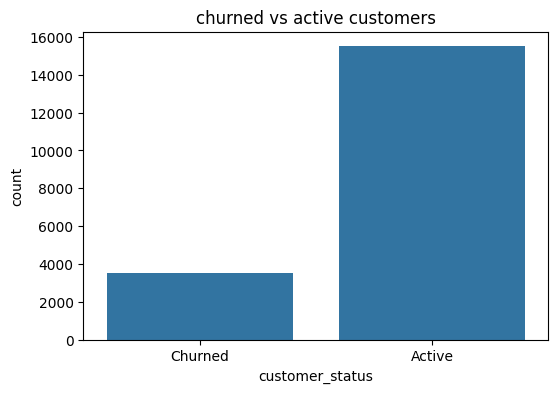

In [6]:
counts = dict(Counter(customers_data["customer_status"]))
display(f"Total Customers : {len(customers_data)}")
display(f"No of Churns : {counts["Churned"]}")
display(f"No of Actives : {counts["Active"]}")
plt.figure(figsize = (6,4))
sns.countplot(x = customers_data["customer_status"])
plt.title("churned vs active customers")
plt.show()

In [7]:
plans_data = pd.read_sql_query(
    """
    SELECT *
    FROM plans;
    
    """,
    con = engine
)
plans_data.head()

,plan_id,plan_name,product_line,billing_cycle,monthly_charge,data_quota_gb,voice_minutes,sms_count,segment,is_active
0,PL001,Prepaid Saver 199,Prepaid Mobile,Monthly,199.00,28,-1,300,Mass,Yes
1,PL002,Prepaid Smart 299,Prepaid Mobile,Monthly,299.00,56,-1,-1,Mass,Yes
2,PL003,Prepaid Plus 399,Prepaid Mobile,Monthly,399.00,84,-1,-1,Value,Yes
3,PL004,Prepaid Data 449,Prepaid Mobile,Monthly,449.00,112,-1,-1,Value,Yes
4,PL005,Prepaid Annual 2999,Prepaid Mobile,Annual,250.00,730,-1,-1,Value,Yes



Churn Rate by Billing Cycle : 



billing_cycle
Annual     1.91
Monthly   16.55
Name: customer_status, dtype: float64

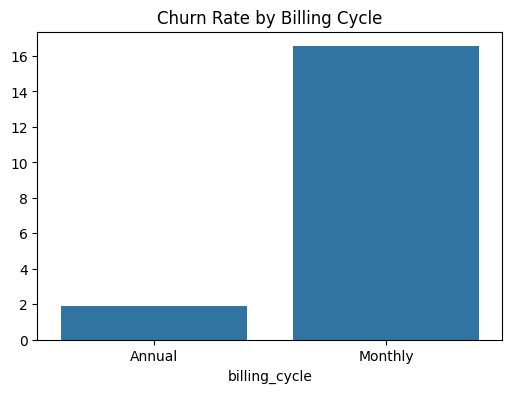

In [8]:
customers_plans = customers_data.merge(plans_data, on = "plan_id" , how = "inner")
total_customers = len(customers_plans)
data_by_billing_cycle = customers_plans[customers_plans["customer_status"] == "Churned"].groupby("billing_cycle")["customer_status"].count()
print("", end = "\n")
print("Churn Rate by Billing Cycle : ")
print("", end = "\n")
Churn_Rate_by_Billing_Cycle = 100 * data_by_billing_cycle / total_customers
display(Churn_Rate_by_Billing_Cycle)
print("", end = "\n")

plt.figure(figsize = (6,4))
sns.barplot(x = Churn_Rate_by_Billing_Cycle.index , y = Churn_Rate_by_Billing_Cycle.values)
plt.title("Churn Rate by Billing Cycle")
plt.show()

In [9]:
customers_data["tenure_months"].describe()

count   19000.00
mean       76.93
std        48.17
min         0.00
25%        34.00
50%        76.00
75%       122.00
max       146.00
Name: tenure_months, dtype: float64

C:\Users\KISHORE\AppData\Local\Temp\ipykernel_33164\1574225747.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_customers_cp_chorned = customers_cp_chorned.groupby("Tenure_Category")["customer_id"].count()


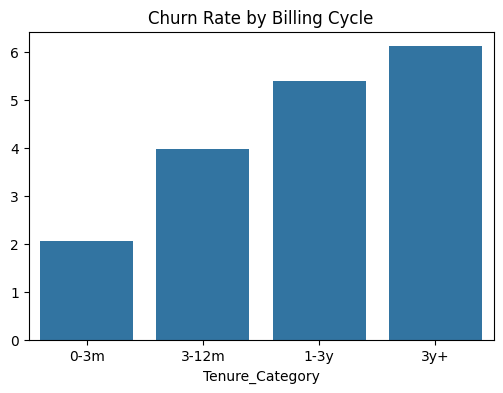

In [10]:
customers_cp = customers_data.copy()
bin_labels = ["0-3m", "3-12m", "1-3y", "3y+"]
bin_edges = [0,3,12,36,146]
customers_cp["Tenure_Category"] = pd.cut(customers_cp["tenure_months"], bins = bin_edges, labels = bin_labels)
total_customers = len(customers_cp)
customers_cp_chorned = customers_cp[customers_cp["customer_status"] == "Churned"]
group_customers_cp_chorned = customers_cp_chorned.groupby("Tenure_Category")["customer_id"].count()
chrun_rate = 100 * group_customers_cp_chorned / total_customers
plt.figure(figsize = (6,4))
sns.barplot(x = chrun_rate.index, y = chrun_rate.values)
plt.title("Churn Rate by Billing Cycle")
plt.show()

In [11]:
complaints_data = pd.read_sql_query(
    """
    SELECT *
    FROM complaints;
    
    """,
    con = engine
)
plans_data.head()

,plan_id,plan_name,product_line,billing_cycle,monthly_charge,data_quota_gb,voice_minutes,sms_count,segment,is_active
0,PL001,Prepaid Saver 199,Prepaid Mobile,Monthly,199.00,28,-1,300,Mass,Yes
1,PL002,Prepaid Smart 299,Prepaid Mobile,Monthly,299.00,56,-1,-1,Mass,Yes
2,PL003,Prepaid Plus 399,Prepaid Mobile,Monthly,399.00,84,-1,-1,Value,Yes
3,PL004,Prepaid Data 449,Prepaid Mobile,Monthly,449.00,112,-1,-1,Value,Yes
4,PL005,Prepaid Annual 2999,Prepaid Mobile,Annual,250.00,730,-1,-1,Value,Yes



Churn Rate by Complaint status : 



status
Resolved     10.64
Unresolved   12.21
Name: customer_status, dtype: float64

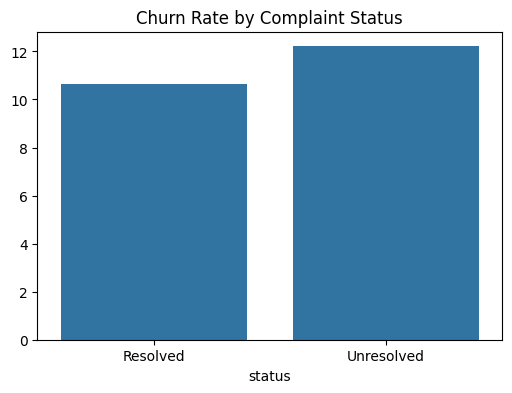

In [12]:
customers_complaints = customers_data.merge(complaints_data, on = "customer_id" , how = "inner")
total_customers = len(customers_complaints)
data_by_complaint_status = customers_complaints[customers_complaints["customer_status"] == "Churned"].groupby("status")["customer_status"].count()
print("", end = "\n")
print("Churn Rate by Complaint status : ")
print("", end = "\n")
Churn_Rate_by_complaints_status = 100 * data_by_complaint_status / total_customers
display(Churn_Rate_by_complaints_status)
print("", end = "\n")

plt.figure(figsize = (6,4))
sns.barplot(x = Churn_Rate_by_complaints_status.index , y = Churn_Rate_by_complaints_status.values)
plt.title("Churn Rate by Complaint Status")
plt.show()


total customers :  16584

churn Rate : 
customer_segment
Enterprise   1.00
Mass         4.72
Premium      7.74
Value        7.69
Name: customer_status, dtype: float64



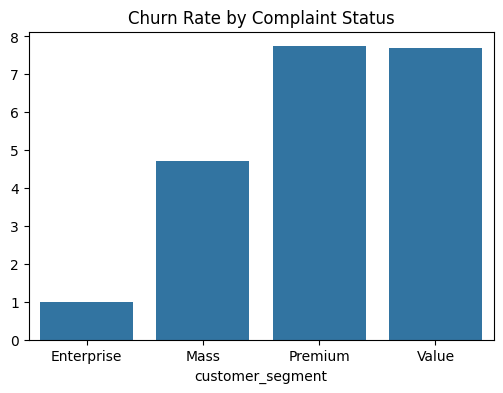

In [13]:
grouped_by_customer_segment = customers_data[customers_data["customer_status"] == "Churned"].groupby("customer_segment")["customer_status"].count()
churn_rate = 100 * grouped_by_customer_segment / total_customers

print("", end = "\n")
print("total customers : ", total_customers)
print("", end = "\n")
print("churn Rate : ")
print(churn_rate)
print("", end = "\n")
plt.figure(figsize = (6,4))
sns.barplot(x = churn_rate.index , y = churn_rate.values)
plt.title("Churn Rate by Complaint Status")
plt.show()

In [14]:
customers_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19000 entries, 0 to 18999
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          19000 non-null  object 
 1   first_name           19000 non-null  object 
 2   last_name            19000 non-null  object 
 3   gender               19000 non-null  object 
 4   date_of_birth        19000 non-null  object 
 5   age                  19000 non-null  int64  
 6   email                18256 non-null  object 
 7   phone_number         19000 non-null  object 
 8   address              18620 non-null  object 
 9   city_id              19000 non-null  object 
 10  city_name            19000 non-null  object 
 11  state_id             19000 non-null  object 
 12  pin_code             19000 non-null  object 
 13  city_tier            19000 non-null  object 
 14  region_id            19000 non-null  object 
 15  occupation           19000 non-null 

In [15]:
cities_data = pd.read_sql_query(
    """
    SELECT *
    FROM cities;
    
    """,
    con = engine
)
cities_data.head()

,city_id,city_name,state_id,state_name,zone,region_id,tier,pin_prefix
0,CT0001,New Delhi,ST001,Delhi,North,RG01,Metro,110
1,CT0002,Mumbai,ST010,Maharashtra,West,RG02,Metro,400
2,CT0003,Bengaluru,ST015,Karnataka,South,RG03,Metro,560
3,CT0004,Chennai,ST016,Tamil Nadu,South,RG03,Metro,600
4,CT0005,Kolkata,ST022,West Bengal,East,RG04,Metro,700



total customers :  19000

churn Rate : 


city_name_y
Agartala     21.56
Agra         20.00
Ahmedabad    15.85
Aizawl       30.18
Ajmer        17.19
Amritsar     20.21
Aurangabad   17.19
Belagavi     15.62
Bengaluru    18.97
Bhagalpur    20.41
Name: customer_status, dtype: float64

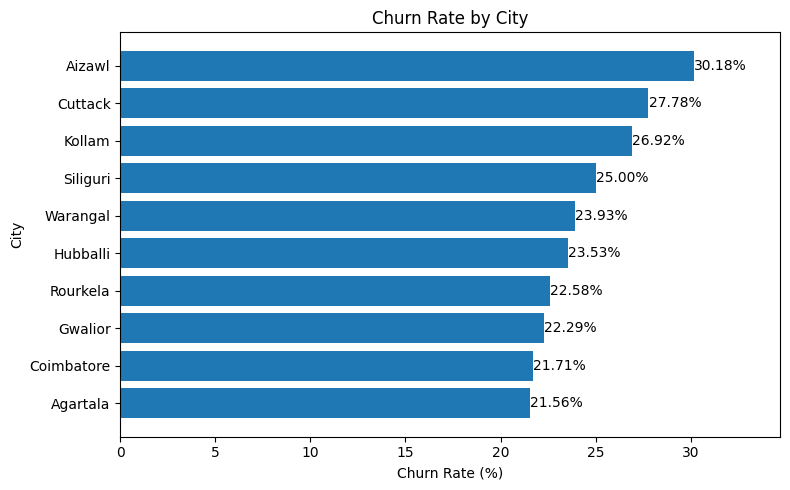

In [17]:
customers_cities = customers_data.merge(cities_data, on="city_id",how="inner")
total_by_city = (customers_cities.groupby("city_name_y")["customer_status"].count())
churned_by_city = (customers_cities[customers_cities["customer_status"] == "Churned"].groupby("city_name_y")["customer_status"].count())

churn_rate = (100 * churned_by_city / total_by_city).fillna(0)

print("", end = "\n")
print("total customers : ", total_customers)
print("", end = "\n")
print("churn Rate : ")
display(churn_rate.head(10))
print("", end = "\n")

plt.figure(figsize = (8,5))
bars = plt.barh(churn_rate.sort_values(ascending=True).tail(10).index , churn_rate.sort_values(ascending=True).tail(10).values)

for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        ha="left"
    )

plt.xlabel("Churn Rate (%)")
plt.ylabel("City")
plt.title("Churn Rate by City")

plt.xlim(0, churn_rate.max() * 1.15)

plt.tight_layout()
plt.show()

In [19]:
data_usage_data = pd.read_sql_query(
    """
    SELECT *
    FROM usage_data;
    
    """,
    con = engine
)
data_usage_data.head()

,usage_id,customer_id,usage_month,data_gb_used,data_sessions
0,UD00000001,C0000001,03-2026,22.35,1047
1,UD00000002,C0000001,02-2026,13.24,61
2,UD00000003,C0000001,01-2026,13.09,1039
3,UD00000004,C0000002,03-2026,167.23,442
4,UD00000005,C0000002,02-2026,109.72,481


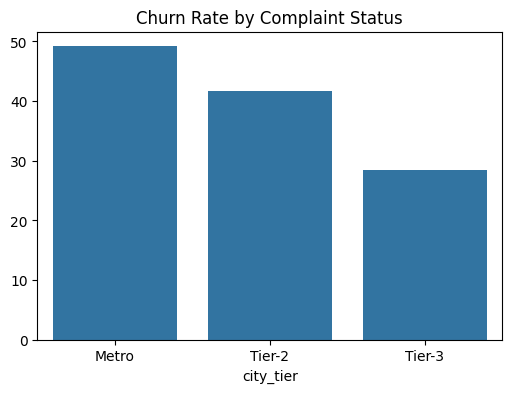

In [20]:
customers_data_usage = customers_data.merge(data_usage_data, on="customer_id",how="inner")

avg_data_usage_by_tier = customers_data_usage.groupby("city_tier")["data_gb_used"].mean()

plt.figure(figsize = (6,4))
sns.barplot(x = avg_data_usage_by_tier.index , y = avg_data_usage_by_tier.values)
plt.title("Churn Rate by Complaint Status")
plt.show()

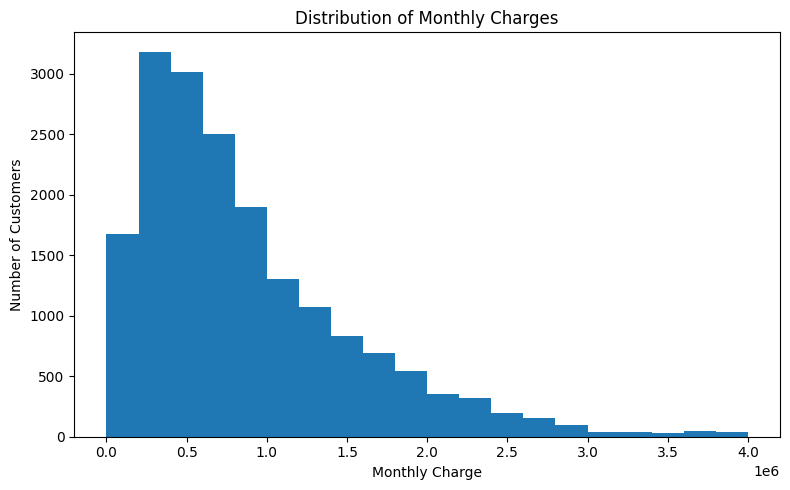

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(customers_data["annual_income_inr"],bins=20)
plt.xlabel("Monthly Charge")
plt.ylabel("Number of Customers")
plt.title("Distribution of Monthly Charges")
plt.tight_layout()
plt.show()

In [23]:
data_usage_data = pd.read_sql_query(
    """
    SELECT *
    FROM network_quality;
    
    """,
    con = engine
)
data_usage_data.head()

,record_id,customer_id,city_id,month,avg_signal_strength_dbm,dropped_call_rate_pct,avg_download_speed_mbps,network_downtime_hours
0,NQ00000001,C0000001,CT0026,03-2026,-74.30,3.15,25.10,0.87
1,NQ00000002,C0000001,CT0026,02-2026,-74.30,3.39,64.90,0.13
2,NQ00000003,C0000001,CT0026,01-2026,-74.30,1.75,68.70,0.46
3,NQ00000004,C0000002,CT0009,03-2026,-69.90,2.92,73.10,0.17
4,NQ00000005,C0000002,CT0009,02-2026,-69.90,3.02,75.30,0.33


In [24]:
data_usage_data.describe()

,avg_signal_strength_dbm,dropped_call_rate_pct,avg_download_speed_mbps,network_downtime_hours
count,57000.00,57000.00,57000.00,57000.00
mean,-67.99,2.40,49.06,0.72
std,7.84,1.29,22.53,0.63
min,-103.30,0.04,4.40,0.00
25%,-73.30,1.46,30.30,0.27
50%,-68.00,2.23,47.30,0.54
75%,-62.60,3.18,65.50,0.98
max,-50.60,9.82,118.70,6.96


C:\Users\KISHORE\AppData\Local\Temp\ipykernel_33164\3384294737.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signal_category_by_churn = merged[merged["customer_status"] == "Churned"].groupby("signal_category")["customer_status"].count()


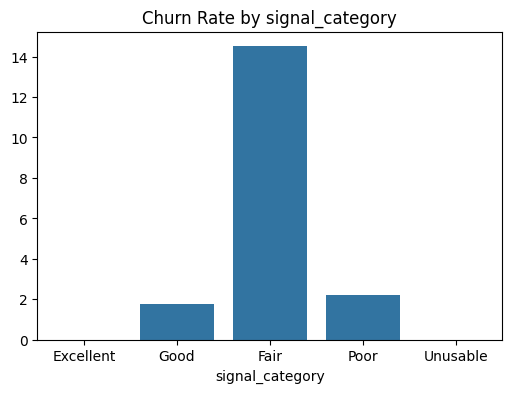

In [30]:
bin_edges = [-120, -100, -80, -60, -40, 0]
bin_labels = ["Excellent", "Good", "Fair", "Poor", "Unusable"]
data_usage_data_cp = data_usage_data.copy()
data_usage_data_cp["signal_category"] = pd.cut(data_usage_data_cp["avg_signal_strength_dbm"], bins = bin_edges, labels = bin_labels)

merged = data_usage_data_cp.merge(customers_data, on = "customer_id", how = "inner")
total_customers = len(merged)
signal_category_by_churn = merged[merged["customer_status"] == "Churned"].groupby("signal_category")["customer_status"].count()
chorn_rate = 100 * signal_category_by_churn / total_customers
plt.figure(figsize = (6,4))
sns.barplot(x = chorn_rate.index , y = chorn_rate.values)
plt.title("Churn Rate by signal_category")
plt.show()

In [31]:
retention_campaigns_data = pd.read_sql_query(
    """
    SELECT *
    FROM retention_campaigns;
    
    """,
    con = engine
)
retention_campaigns_data.head()

,campaign_id,customer_id,campaign_name,offer_type,contact_date,channel,response,retained_flag
0,RTC0000001,C0000004,Renewal Nudge,Annual Plan Discount,04-09-2025,SMS,Declined,Yes
1,RTC0000002,C0000009,Renewal Nudge,Cashback Voucher,08-01-2026,Call,Declined,Yes
2,RTC0000003,C0000015,Loyalty Save,Extra Data 50GB,23-02-2025,WhatsApp,Accepted,Yes
3,RTC0000004,C0000016,At-Risk Outreach,Free OTT 3 Months,08-01-2026,WhatsApp,Accepted,No
4,RTC0000005,C0000017,Loyalty Save,Plan Upgrade Offer,22-05-2025,Email,Accepted,No


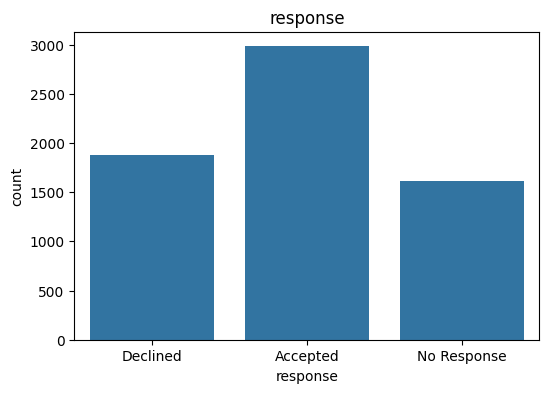

In [32]:
plt.figure(figsize = (6,4))
sns.countplot(x = retention_campaigns_data["response"])
plt.title("response")
plt.show()